In [1]:
import requests
import pandas as pd
import time
import re
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [2]:
def cefr_to_numeric(level: str) -> int
    mapping = {"A1": 1, "A2": 2, "B1": 3, "B2": 4, "C1": 5, "C2": 6, "Не определен": "Не определен", "А1": 1,"А2": 2, "Б1": 3, "Б2": 4, "С1": 5, "С2": 6}
    return mapping.get(level, 0)


def numeric_to_cefr(value: int) -> str:
    mapping = {1: "A1", 2: "A2", 3: "B1", 4: "B2", 5: "C1", 6: "C2", "Не определен": "Не определен"}
    return mapping.get(value, "Не определен")

In [3]:
def extract_cefr_level(response: str) -> str:
    if not response:
        return "Ошибка"
    
    response_upper = response.upper().strip()
    levels = ["A1", "A2", "B1", "B2", "C1", "C2", "А1", "А2", "Б1", "Б2", "С1", "С2"]
    
    for level in levels:
        if level in response_upper:
            return level
    
    return "Не определен"

In [4]:
class RussianOllamaClient:
    def __init__(self, model_name="llama3"):
        self.model_name = model_name
        self.base_url = "http://localhost:11434"
        print(f"Используем модель: {model_name}")
    
    def make_request(self, prompt: str, max_tokens: int = 100) -> str:
        data = {
            "model": self.model_name,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": 0.3,
                "num_predict": max_tokens
            }
        }
        
        try:
            response = requests.post(
                f"{self.base_url}/api/generate", 
                json=data, 
                timeout=120
            )
            
            if response.status_code == 200:
                result = response.json()
                return result['response']
            else:
                print(f"❌ Ошибка {response.status_code}")
                return ""
                
        except Exception as e:
            print(f"❌ Исключение: {e}")
            return ""

In [5]:
client = RussianOllamaClient("llama3:8b")  
    
test_response = client.make_request("Скажи 'тест пройден'")
if test_response:
    print("✅ Модель работает")
else:
    print("❌ Модель не отвечает")

Используем модель: llama3:8b
✅ Модель работает


In [6]:
df = pd.read_csv('ru_cefr_short.csv')
df

,fragment,textbook-assigned cefr level
0,"Весной, летом и осенью почти каждую субботу он...",1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1
2,На каждой двери красные плакаты и красные фона...,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1
...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6
7320,Mapillary использует программное обеспечение д...,6


In [7]:
X_train, X_test, y_train, y_test = train_test_split(df['fragment'], df['textbook-assigned cefr level'], test_size=0.2, random_state=42)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [8]:
texts_to_test = X_test.tolist()
levels_to_test = y_test.tolist()

len(texts_to_test) == len(levels_to_test)

True

In [9]:
def create_few_shot_prompt(text):
    return f'''Ты - эксперт по русскому языку как иностранному (РКИ). Определи уровень CEFR текста на основе следующих критериев:

A1: Очень частотная повседневная лексика, простые предложения, базовые падежи. Глаголы движения без приставок (идти-ходить, ехать-ездить). Предложный падеж с предлогом о, дательный падеж (кому), родительный падеж (нет урока, тетрадь студента). Конструкции с предлогами из, для, без, около, после. Простые предложения или короткие сложноподчиненные с союзами что, потому что. Конструкции типа ""мне холодно"". Достижение уровня для удовлетворения элементарных коммуникативных потребностей.

A2: Частотная лексика, глаголы движения с приставками (по-, при-, в-, вы-, пере-, под-, до-, об-, за-) в прошедшем и будущем времени. Фразы с ""ещё"" и ""уже"", формы императива, простые случаи косвенной речи, возвратные глаголы и местоимения. Сложносочиненные предложения с союзами и, или, а, но. Короткие сложноподчиненные предложения с придаточными времени, условия, цели (когда, если, чтобы), предложения с союзным словом ""который"". Расширение сферы межличностного общения в стандартных ситуациях повседневной жизни.

B1: Абстрактная лексика, причастия/деепричастия, причастные и деепричастные обороты, формы пассива. Глаголы движения (бежать-бегать, лететь-летать и др.) с приставками. Собирательные числительные (двое), неопределенные местоимения (кто-то), сравнительная и превосходная степень прилагательных. Сложносочиненные предложения с союзами только, однако, либо. Сложноподчиненные предложения со словами там, туда, оттуда, из-за, благодаря, несмотря на, хотя, для того чтобы, в то время как, пока. Условные конструкции ""если бы"". Подготовка к обучению в вузах, поддержание социально-делового общения.

B2: Стилистически окрашенная лексика, лексика научного и официально-делового стиля, фразеология. Активно используются деепричастные обороты, страдательный залог, причастия, разнообразные союзы и предлоги, сложная структура предложений. Предложения с безличными глаголами (хочется), нетипичные случаи выражения субъекта и предиката, инфинитив в позиции подлежащего. Конструкции с выражением субъективной оценки: частицы пусть, конструкции с должен, вынужден. Конструкции с наречиями негде, некогда, предложения с предлогами при, вместо, ради. Обучение в вузе, использование различных стилей языка, свободное понимание СМИ.

C1: Сложная лексика, длинные предложения с придаточными, высокая степень номинализации, возможна устаревшая или книжная лексика. Всё многообразие типов придаточных предложений. Длинные предложения с несколькими придаточными и сложными союзами: как вдруг, в то время как, после того как, с тех пор как, благодаря тому что, вследствие того что, поскольку, так что, с тем чтобы, будто, словно. Предложения с предикатным, присловным и противопоставительным отрицанием. Неопределённо-личные и безличные конструкции. Владение различными стилями языка, способность воспринимать информацию во всей полноте в различных ситуациях общения.

C2: Научный стиль, идиомы, сложные синтаксические конструкции. Синтаксические модели выражения логической связи: что является чем, представляет собой, относится к, предназначено для, обозначается как, ведет к чему, состоит из чего, из чего следует что, характеризуется чем. Устойчивые обороты речи, идиомы. Владение языком на профессиональном уровне, включая преподавание РКИ и научно-исследовательскую работу.

Текст для анализа: ""Я живу в маленьком городе""
Уровень CEFR: A1

Текст для анализа: ""Летом в деревне мне нравится купаться и делать что-нибудь в саду""
Уровень CEFR: A2

Текст для анализа: ""В прошлом году мы ездили в Сочи, где каждый день купались в море и ели вкусные фрукты""
Уровень CEFR: A2

Текст для анализа: ""Когда я впервые приехал в Москву, меня удивило, как быстро здесь меняется погода""
Уровень CEFR: B1

Текст для анализа: ""Гуляя по Москве, мы наткнулись на маленький зеленый дворик, притаившийся за главной улицей""
Уровень CEFR: B1

Текст для анализа: ""Несмотря на дождливую погоду, наш концерт под открытым небом не просто состоялся, а прогремел: мы собрали толпу преданных слушателей, подпевавших нам на все лады""
Уровень CEFR: B2

Текст для анализа: ""Хотя статистические данные указывают на спад интереса к чтению, в некоторых регионах можно наблюдать обратную тенденцию, обусловленную развитием местных библиотечных инициатив""
Уровень CEFR: C1

Текст для анализа: ""Покачиваясь вместе с вагоном, мы преодолевали бескрайние просторы Сибири, и, чем дальше мы уезжали от столиц и больших городов, тем чаще ловили себя на мысли, что сама протяжённость этого пути, постоянная смена пейзажа и наших попутчиков, становится самоцелью путешествия, расстояния измеряются здесь уже не километрами, а прожитыми мгновениями: как пелось в той песне, “есть только миг”""
Уровень CEFR: C2

Текст для анализа: ""{text}""

Верни ТОЛЬКО уровень CEFR (A1, A2, B1, B2, C1, C2) без дополнительных объяснений.'''

In [10]:
model_responses = []
predicted_levels = []

print(f"Анализируем {len(texts_to_test)} текстов...")

for i in range(len(texts_to_test)):
    text, real_level = texts_to_test[i], levels_to_test[i]
    
    print(f"\nТекст {i+1}/{len(X_test)}: {text[:80]}...")
    
    prompt = create_few_shot_prompt(text)
    response = client.make_request(prompt)
    level = extract_cefr_level(response)
    
    print(f"    Реальный уровень {numeric_to_cefr(real_level)}")
    print(f"    Предсказание модели: {level}")

    predicted_levels.append(cefr_to_numeric(level))
    model_responses.append(response)

Анализируем 1465 текстов...

Текст 1/1465: Организм после бани легче переносит физические нагрузки, интенсивную работу, луч...
    Реальный уровень B1
    Предсказание модели: B2

Текст 2/1465: Через полстолетия в моду входит не просто стройность, а настоящая худоба. В шест...
    Реальный уровень A2
    Предсказание модели: B2

Текст 3/1465: Одного беглого взгляда на кривую саврасовскую берёзку хватит, чтобы вспомнить ур...
    Реальный уровень B2
    Предсказание модели: C2

Текст 4/1465: С развитием науки в МГУ открывались новые и новые факультеты, например, факульте...
    Реальный уровень B1
    Предсказание модели: A1

Текст 5/1465: Обычно первые числа мая объявляются нерабочими, поэтому люди гуляют по городу ил...
    Реальный уровень B2
    Предсказание модели: B1

Текст 6/1465: «Проекты о путешествиях Познера и Урганта», Первый канал. Первая совместная рабо...
    Реальный уровень B1
    Предсказание модели: A1

Текст 7/1465: Телевидение вошло в наши дома очень скромно: через 

In [11]:
df_pred = pd.DataFrame(columns=['text', 'real_level', 'predicted_level', 'model_response'])
df_pred['text'] = texts_to_test
df_pred['real_level'] = levels_to_test
df_pred['predicted_level'] = predicted_levels
df_pred['model_response'] = model_responses
df_pred

,text,real_level,predicted_level,model_response
0,Организм после бани легче переносит физические...,3,4,Уровень CEFR: B2
1,Через полстолетия в моду входит не просто стро...,2,4,"Текст для анализа: """"Через полстолетия в моду ..."
2,Одного беглого взгляда на кривую саврасовскую ...,4,6,"Текст: """"Одного беглого взгляда на кривую савр..."
3,С развитием науки в МГУ открывались новые и но...,3,1,"Based on the criteria, I determine the level o..."
4,Обычно первые числа мая объявляются нерабочими...,4,3,Обычно первые числа мая объявляются нерабочими...
...,...,...,...,...
1460,"Лишний вес не только вреден для здоровья, но и...",4,4,"Лишний вес не только вреден для здоровья, но и..."
1461,"Русские люди встречают Новый год ночью, в 12 ч...",1,2,"Русский текст: """"Русские люди встречают Новый ..."
1462,Во второй раз можно париться уже на верхней по...,3,2,Уровень CEFR: A2
1463,Несмотря на то что многие годы павловопосадски...,4,3,Уровень CEFR: B1


In [16]:
df_pred.to_csv("few-shot.csv", index=False)

In [13]:
df_pred['predicted_level'].unique()

array([4, 6, 1, 3, 2, 5, 'Не определен'], dtype=object)

In [17]:
df_pred[df_pred['predicted_level'] == 'Не определен']

,text,real_level,predicted_level,model_response
278,"Между двух фортепиано, шкафами и письменными с...",5,Не определен,Международный стандарт CEFR - это обзор языка ...
1395,Прежде чем легитимировать столь важное для сем...,5,Не определен,"Приведенный текст: """"Прежде чем легитимировать..."


In [25]:
df_eval = df_pred[
    df_pred['predicted_level'].notna() &
    (df_pred['predicted_level'] != 'Не определен')
].copy()

y_true = df_eval['real_level'].tolist()
y_pred = df_eval['predicted_level'].tolist()

print(f"Точность: {accuracy_score(y_true, y_pred):.4f}")

print(f"F1-score micro: {f1_score(y_true, y_pred, average='micro',  zero_division=0):.4f}")
print(f"F1-score macro: {f1_score(y_true, y_pred, average='macro',  zero_division=0):.4f}")
print(f"F1-score weighted: {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")

print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f}")

Точность: 0.2522
F1-score micro: 0.2522
F1-score macro: 0.1753
F1-score weighted: 0.2369
MAE: 1.3274


In [26]:
print(f"{accuracy_score(y_true, y_pred):.4f}")

print(f"{f1_score(y_true, y_pred, average='micro',  zero_division=0):.4f}")
print(f"{f1_score(y_true, y_pred, average='macro',  zero_division=0):.4f}")
print(f"{f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")

print(f"{mean_absolute_error(y_true, y_pred):.4f}")

0.2522
0.2522
0.1753
0.2369
1.3274


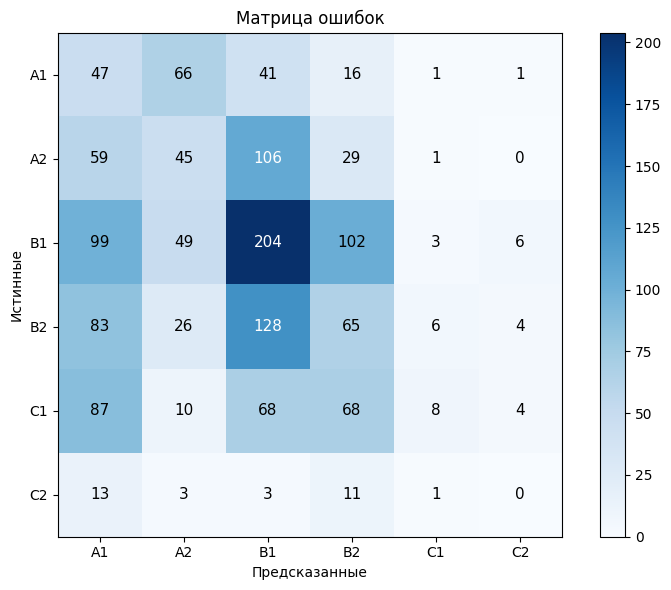

In [29]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        ax.text(
            j, i,
            f"{value:.0f}",
            ha="center",
            va="center",
            color="white" if value > cm.max() / 2 else "black",
            fontsize=11
        )

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')

plt.colorbar(im)
plt.tight_layout()
plt.show()